# Task 4 — Email Spam Detection with Machine Learning

## Objective

The objective of this project is to build a Natural Language Processing (NLP) binary classification model capable of distinguishing spam messages from legitimate (ham) messages.

The project covers:
- Exploratory Data Analysis
- Text preprocessing
- TF-IDF feature extraction
- Machine Learning classification
- Model evaluation
- Comparison between different classifiers
- Word cloud visualization of spam vocabulary
- Saving the final model and vectorizer for reuse


In [1]:
# Import Libraries
import os
import re
import string
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Folders used to persist outputs generated by this notebook
IMAGES_DIR = "../images"
MODELS_DIR = "../models"
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Make plots reproducible / consistent
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
#Load Dataset:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
#Understand Dataset
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (5572, 5)

Columns:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
df.describe(include="all")

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [7]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [8]:
df = df[["v1", "v2"]]

In [9]:
df.columns = ["label", "message"]

In [10]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 403


In [12]:
df = df.drop_duplicates()

In [13]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


## Dataset Description

The dataset contains text messages labeled as either:

- **ham** — legitimate messages
- **spam** — unwanted messages

Each observation represents one message that will be used to train a binary classification model.

In [14]:
class_counts = df["label"].value_counts()

print(class_counts)

label
ham     4516
spam     653
Name: count, dtype: int64


In [15]:
class_percentages = df["label"].value_counts(normalize=True) * 100

print(class_percentages)

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


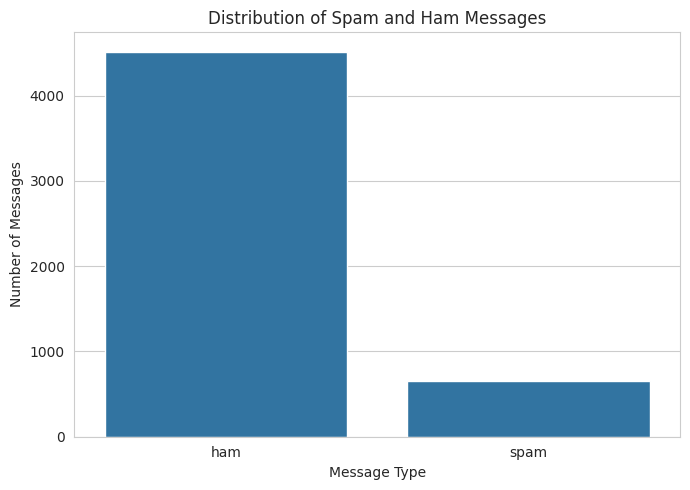

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Class Distribution Analysis

The dataset contains significantly more legitimate (ham) messages than spam messages.

This indicates that the dataset is imbalanced. Therefore, accuracy alone should not be used to evaluate the models because a model could achieve high accuracy simply by predicting the majority class most of the time.

For this reason, precision, recall, F1-score, and the confusion matrix will also be considered.

In [17]:
#save data to Cleaned.csv:
df.to_csv("../data/spam_Cleaned.csv", index=False)

## NLTK Resources

The `stopwords` corpus from NLTK is required for the text preprocessing step below. It only needs to be downloaded once per environment.

In [18]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

## Text Preprocessing

Text data cannot be directly used by most machine learning algorithms. Therefore, the messages are transformed into a cleaner representation.

The preprocessing steps include:

1. Converting text to lowercase to make words such as "FREE" and "free" equivalent.
2. Removing punctuation that usually does not provide useful information for this classification task.
3. Removing numbers to reduce unnecessary variation.
4. Removing common English stopwords.
5. Producing a cleaned text representation that can be transformed into numerical features.

In [20]:
#Create Preprocessing Function:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join words
    return " ".join(words)

In [21]:
#Apply Preprocessing:
df["clean_message"] = df["message"].apply(preprocess_text)
#Compare:
df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


## Word Cloud Visualization

A word cloud provides a quick, intuitive view of the vocabulary that is most characteristic of each class. Words that appear more frequently in the cleaned text are rendered larger.

This is purely exploratory — it does not feed into the model — but it helps confirm that spam messages are dominated by promotional/marketing vocabulary (e.g. "free", "call", "win", "text", "claim"), which supports why a bag-of-words / TF-IDF approach is effective for this task.

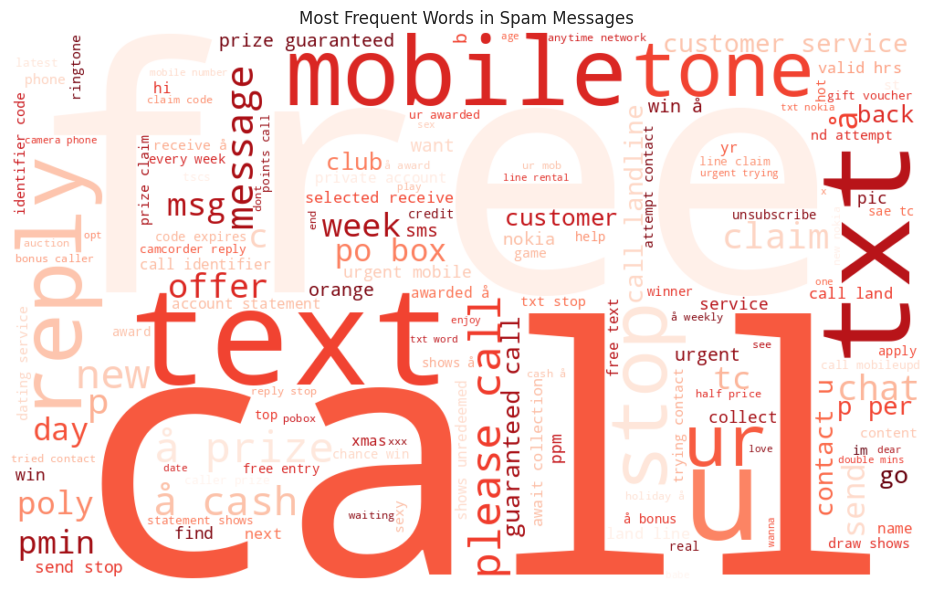

In [22]:
spam_text = " ".join(df.loc[df["label"] == "spam", "clean_message"])
ham_text = " ".join(df.loc[df["label"] == "ham", "clean_message"])

spam_wc = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="Reds",
    max_words=150,
    random_state=RANDOM_STATE
).generate(spam_text)

plt.figure(figsize=(10, 6))
plt.imshow(spam_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Spam Messages")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/wordcloud_spam.png", dpi=150, bbox_inches="tight")
plt.show()

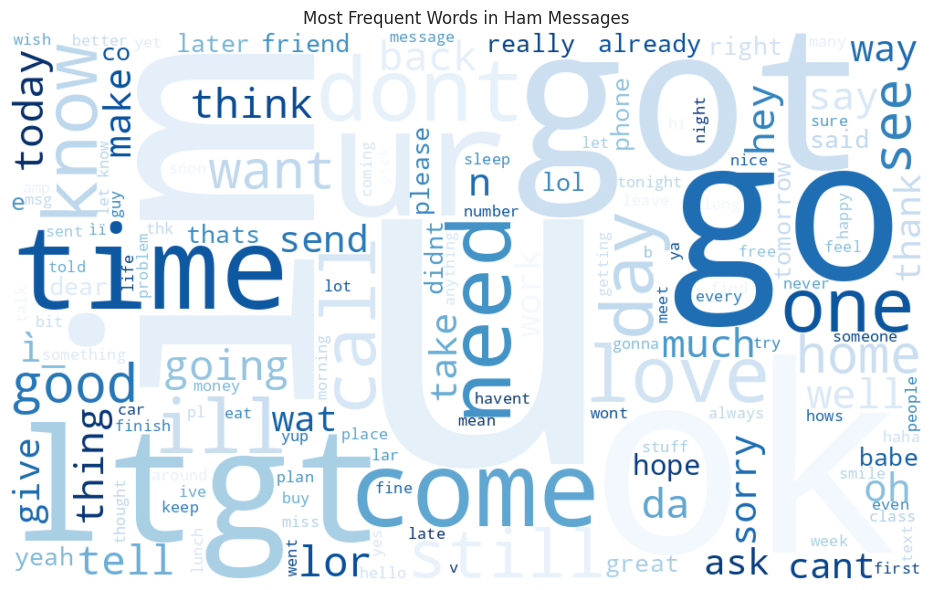

In [23]:
ham_wc = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="Blues",
    max_words=150,
    random_state=RANDOM_STATE
).generate(ham_text)

plt.figure(figsize=(10, 6))
plt.imshow(ham_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Ham Messages")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/wordcloud_ham.png", dpi=150, bbox_inches="tight")
plt.show()

## TF-IDF Feature Extraction

TF-IDF stands for **Term Frequency-Inverse Document Frequency**.

It converts text into numerical features that machine learning algorithms can process.

- **Term Frequency (TF):** measures how frequently a word appears in a document.
- **Inverse Document Frequency (IDF):** gives lower importance to words that appear in many documents and higher importance to words that are more specific to particular documents.

The TF-IDF representation therefore gives higher importance to informative words while reducing the influence of very common words.

The resulting matrix contains one row per message and one column per vocabulary term.

In [24]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

In [25]:
#train / test split  : 
X = df["clean_message"]
y = df["label"]
#convert label :
y = y.map({
    "ham": 0,
    "spam": 1
})
#Split:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
#Fit TF-IDF only on Training Data (avoids data leakage from the test set):
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)
#check dimensions:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4135, 5000)
Testing shape: (1034, 5000)


## Model 1 — Multinomial Naive Bayes

In [26]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)
#prediction:
y_pred_nb = nb_model.predict(X_test_tfidf)
#Evaluate Naive Bayes:
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Ham", "Spam"]
))

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Naive Bayes")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-score :", nb_f1)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.75      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.92      1034
weighted avg       0.97      0.97      0.97      1034

Naive Bayes
Accuracy : 0.9671179883945842
Precision: 0.98989898989899
Recall   : 0.7480916030534351
F1-score : 0.8521739130434782


## Model 2 — Logistic Regression

In [27]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

lr_model.fit(X_train_tfidf, y_train)
#prediction:
y_pred_lr = lr_model.predict(X_test_tfidf)
#Evaluation:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Ham", "Spam"]
))
#Metrics:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-score :", lr_f1)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.99      0.65      0.78       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.88      1034
weighted avg       0.96      0.95      0.95      1034

Logistic Regression
Accuracy : 0.9545454545454546
Precision: 0.9883720930232558
Recall   : 0.648854961832061
F1-score : 0.783410138248848


## Confusion Matrix — Naive Bayes

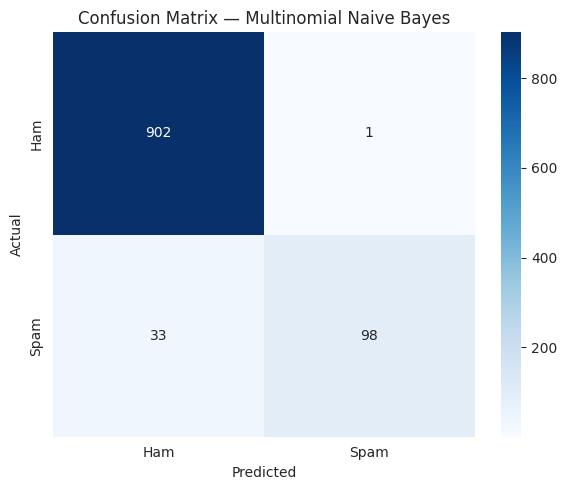

In [28]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix — Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/confusion_matrix_naive_bayes.png", dpi=150, bbox_inches="tight")
plt.show()

## Confusion Matrix — Logistic Regression

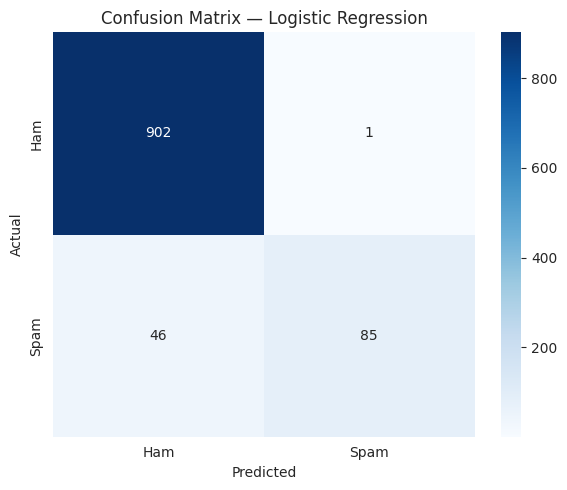

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/confusion_matrix_logistic_regression.png", dpi=150, bbox_inches="tight")
plt.show()

## Why Is Recall Important for Spam Detection?

Recall is particularly important in spam detection because it measures the proportion of actual spam messages that the model successfully identifies.

A false negative occurs when a spam message is incorrectly classified as legitimate (ham).

For example, if the model misses a large number of spam messages, those unwanted or potentially harmful messages may reach the user's inbox.

Therefore, a high recall helps minimize false negatives and ensures that most spam messages are detected.

However, recall should not be maximized blindly. A model with very high recall could incorrectly classify many legitimate messages as spam. Therefore, precision and F1-score should also be considered when selecting the final model.

## Model Comparison

In [30]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1-score": [
        nb_f1,
        lr_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Multinomial Naive Bayes,0.967118,0.989899,0.748092,0.852174
1,Logistic Regression,0.954545,0.988372,0.648855,0.783410


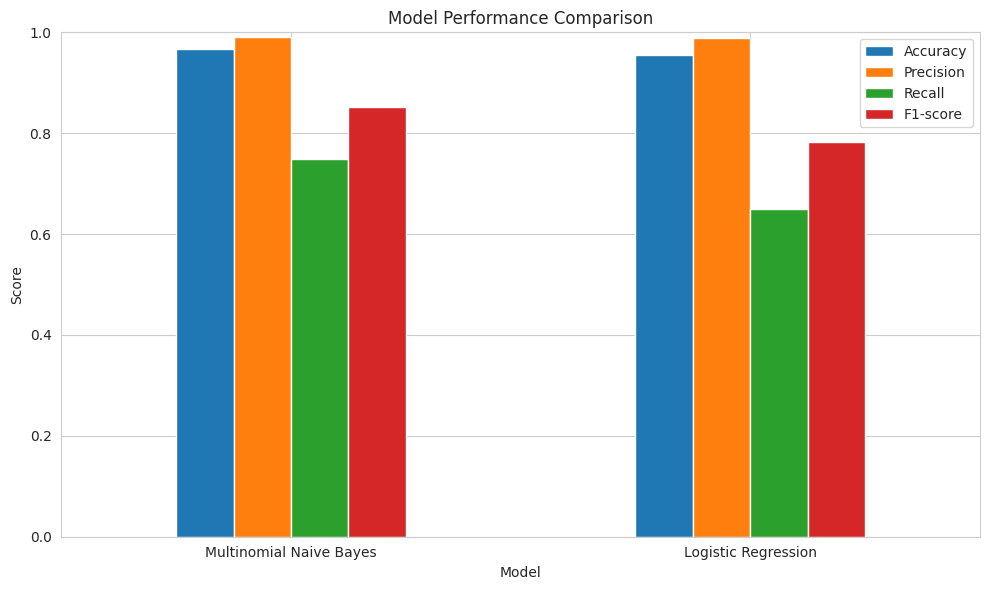

In [31]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Selecting and Saving the Final Model

Based on the comparison above, the model with the best F1-score (the harmonic mean of precision and recall) is selected as the final model, since F1 gives a balanced view that accounts for the class imbalance in this dataset.

Both the fitted **TF-IDF vectorizer** and the trained **classifier** are saved together in a single pickle file. Both are required at inference time: raw text must first be transformed using the *same* fitted vectorizer before it can be passed to the classifier.

In [32]:
models = {
    "Multinomial Naive Bayes": (nb_model, nb_f1),
    "Logistic Regression": (lr_model, lr_f1),
}

best_model_name = max(models, key=lambda name: models[name][1])
best_model = models[best_model_name][0]

print(f"Best model based on F1-score: {best_model_name} (F1 = {models[best_model_name][1]:.4f})")

artifact = {
    "vectorizer": tfidf,
    "model": best_model,
    "model_name": best_model_name,
    "label_map": {"ham": 0, "spam": 1},
}

with open(f"{MODELS_DIR}/tfidf_naivebayes.pkl", "wb") as f:
    pickle.dump(artifact, f)

print(f"Saved best model + vectorizer to {MODELS_DIR}/tfidf_naivebayes.pkl")

Best model based on F1-score: Multinomial Naive Bayes (F1 = 0.8522)
Saved best model + vectorizer to ../models/tfidf_naivebayes.pkl


## Inference Example

The cell below demonstrates how to reload the saved artifact and use it to classify a brand-new, unseen message — exactly as it would be used in a real application.

In [33]:
with open(f"{MODELS_DIR}/tfidf_naivebayes.pkl", "rb") as f:
    loaded = pickle.load(f)

loaded_vectorizer = loaded["vectorizer"]
loaded_model = loaded["model"]

def predict_message(raw_text: str) -> str:
    cleaned = preprocess_text(raw_text)
    vect = loaded_vectorizer.transform([cleaned])
    pred = loaded_model.predict(vect)[0]
    return "SPAM" if pred == 1 else "HAM"

sample_messages = [
    "Congratulations! You've won a free ticket to Bahamas, call now to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow?",
]

for msg in sample_messages:
    print(f"[{predict_message(msg)}] {msg}")

[SPAM] Congratulations! You've won a free ticket to Bahamas, call now to claim your prize!
[HAM] Hey, are we still meeting for lunch tomorrow?


## Final Conclusion

This project demonstrated how Natural Language Processing and machine learning can be used to automatically classify messages as spam or ham.

The dataset was cleaned and analyzed before applying text preprocessing techniques such as lowercase conversion, punctuation removal, and stopword removal.

TF-IDF was then used to transform the text messages into numerical features.

Two classification algorithms were trained and evaluated:
- Multinomial Naive Bayes
- Logistic Regression

The models were compared using accuracy, precision, recall, and F1-score.

Based on the evaluation results, the model with the best overall balance between precision, recall, and F1-score (highest F1-score) was selected and persisted to disk together with its TF-IDF vectorizer.

Recall was particularly important because false negatives represent spam messages that are incorrectly classified as legitimate messages.

Overall, the project demonstrates that traditional machine learning algorithms combined with TF-IDF can provide an effective, lightweight, and interpretable solution for spam detection.

### Possible Future Improvements
- Try additional models (Linear SVM, Random Forest, Gradient Boosting).
- Apply resampling techniques (e.g. SMOTE) or class weighting to address class imbalance more directly.
- Use k-fold cross-validation and hyperparameter tuning (`GridSearchCV`) for more robust model selection.
- Apply stemming/lemmatization during preprocessing.
- Experiment with word embeddings (Word2Vec, GloVe) or transformer-based models (e.g. DistilBERT) for potentially higher performance.